In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install facenet_pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 125.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.

In [2]:
import cv2
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from facenet_pytorch import MTCNN

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [4]:
!unzip /content/drive/MyDrive/DeepfakeProject/faces.zip

Streaming output truncated to the last 5000 lines.
  inflating: content/faces/val/real/original__633/f004.jpg  
  inflating: content/faces/val/real/original__633/f001.jpg  
  inflating: content/faces/val/real/original__633/f000.jpg  
  inflating: content/faces/val/real/original__633/f002.jpg  
   creating: content/faces/val/real/original__078/
  inflating: content/faces/val/real/original__078/f003.jpg  
  inflating: content/faces/val/real/original__078/f004.jpg  
  inflating: content/faces/val/real/original__078/f001.jpg  
  inflating: content/faces/val/real/original__078/f000.jpg  
  inflating: content/faces/val/real/original__078/f002.jpg  
   creating: content/faces/val/real/original__836/
  inflating: content/faces/val/real/original__836/f003.jpg  
  inflating: content/faces/val/real/original__836/f004.jpg  
  inflating: content/faces/val/real/original__836/f001.jpg  
  inflating: content/faces/val/real/original__836/f000.jpg  
  inflating: content/faces/val/real/original__836/f002

In [6]:
import sys
sys.path.append('/content/drive/MyDrive/DeepfakeProject')

In [7]:
from models import build_model
from  dataset import DeepfakeDataset

In [8]:
model = build_model('transformer')
model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth
100%|██████████| 74.5M/74.5M [00:00<00:00, 152MB/s]


In [9]:
checkpoint = torch.load(
    f'/content/drive/MyDrive/DeepfakeProject/outputs/checkpoints/best_model.pth',
    map_location=device
)

In [12]:
model.load_state_dict(checkpoint['model_state'])
model.eval()
print(f'Model loaded from epoch {checkpoint["epoch"]}')


Model loaded from epoch 10


In [13]:
mtcnn = MTCNN(
    keep_all=False, device=device,
    post_process=False, min_face_size=60)

In [25]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

In [14]:
NUM_FRAMES=5

In [26]:
def get_face_bbox(video_path, sample_frames=3):
    cap   = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    h     = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w     = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    indices = np.linspace(0, total-1,
                          min(sample_frames, total), dtype=int)
    boxes = []
    for fidx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ret, frame = cap.read()
        if not ret: continue
        rgb    = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        box, _ = mtcnn.detect(Image.fromarray(rgb))
        if box is not None:
            boxes.append(box[0])
    cap.release()
    if not boxes:
        return None, h, w
    return np.mean(boxes, axis=0).astype(int), h, w

def preprocess_video(video_path, num_frames=NUM_FRAMES):

    bbox, h, w = get_face_bbox(video_path)

    if bbox is not None:
        x1, y1, x2, y2 = bbox
        x1 = max(0,   x1 - 30)
        y1 = max(0,   y1 - 30)
        x2 = min(w-1, x2 + 30)
        y2 = min(h-1, y2 + 30)
    else:
        size = min(h, w)
        x1 = (w - size) // 2
        y1 = (h - size) // 2
        x2 = x1 + size
        y2 = y1 + size

    cap     = cv2.VideoCapture(video_path)
    total   = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    indices = np.linspace(0, total-1,
                          min(num_frames, total), dtype=int)
    frames  = []
    raw_frames = []

    for fidx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fidx)
        ret, frame = cap.read()
        if not ret: continue

        crop    = frame[y1:y2, x1:x2]
        resized = cv2.resize(crop, (224,224))
        rgb     = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)

        raw_frames.append(rgb)
        frames.append(transform(Image.fromarray(rgb)))

    cap.release()

    while len(frames) < num_frames:
        frames.append(frames[-1])
        raw_frames.append(raw_frames[-1])

    tensor = torch.stack(frames).unsqueeze(0).to(device)

    return tensor, raw_frames

In [27]:
def predict(video_path):

    print(f'Analyzing: {video_path.split("/")[-1]}')

    tensor, raw_frames = preprocess_video(video_path)

    with torch.no_grad():
        output = model(tensor)
        prob   = torch.sigmoid(output).item()

    label      = 'FAKE' if prob > 0.5 else 'REAL'
    confidence = prob if prob > 0.5 else 1 - prob

    return {
        'label'     : label,
        'confidence': confidence * 100,
        'fake_prob' : prob * 100,
        'real_prob' : (1 - prob) * 100,
        'frames'    : raw_frames
    }

In [28]:
def show_prediction(result, video_name=''):
    label      = result['label']
    confidence = result['confidence']
    frames     = result['frames']
    color      = 'red' if label == 'FAKE' else 'green'

    fig = plt.figure(figsize=(18, 5))

    n = min(len(frames), NUM_FRAMES)
    for i in range(n):
        ax = fig.add_subplot(2, n, i+1)
        ax.imshow(frames[i])
        ax.axis('off')
        ax.set_title(f'f{i}', fontsize=8)

    ax_bar = fig.add_subplot(2, 1, 2)
    ax_bar.barh(['REAL', 'FAKE'],
                [result['real_prob'], result['fake_prob']],
                color=['green', 'red'], alpha=0.7)
    ax_bar.set_xlim(0, 100)
    ax_bar.axvline(50, color='black',
                   linestyle='--', alpha=0.5)
    ax_bar.set_xlabel('Probability (%)')

    for i, v in enumerate([result['real_prob'],
                            result['fake_prob']]):
        ax_bar.text(v + 1, i, f'{v:.1f}%', va='center')

    fig.suptitle(
        f'Prediction: {label}  |  '
        f'Confidence: {confidence:.1f}%  |  {video_name}',
        fontsize=14, fontweight='bold', color=color)

    plt.tight_layout()
    plt.savefig(f'/content/drive/MyDrive/DeepfakeProject/results/inference_{video_name}.png', dpi=150)
    plt.show()
    print(f'\n{"="*40}')
    print(f'  Result     : {label}')
    print(f'  Confidence : {confidence:.1f}%')
    print(f'  Fake prob  : {result["fake_prob"]:.1f}%')
    print(f'  Real prob  : {result["real_prob"]:.1f}%')
    print(f'{"="*40}')

In [ ]:
from google.colab import files

print('Upload a video to test...')
uploaded = files.upload()

for filename in uploaded.keys():
    result = predict(filename)
    show_prediction(result, video_name=filename)

In [29]:
import os

Analyzing: 029.mp4


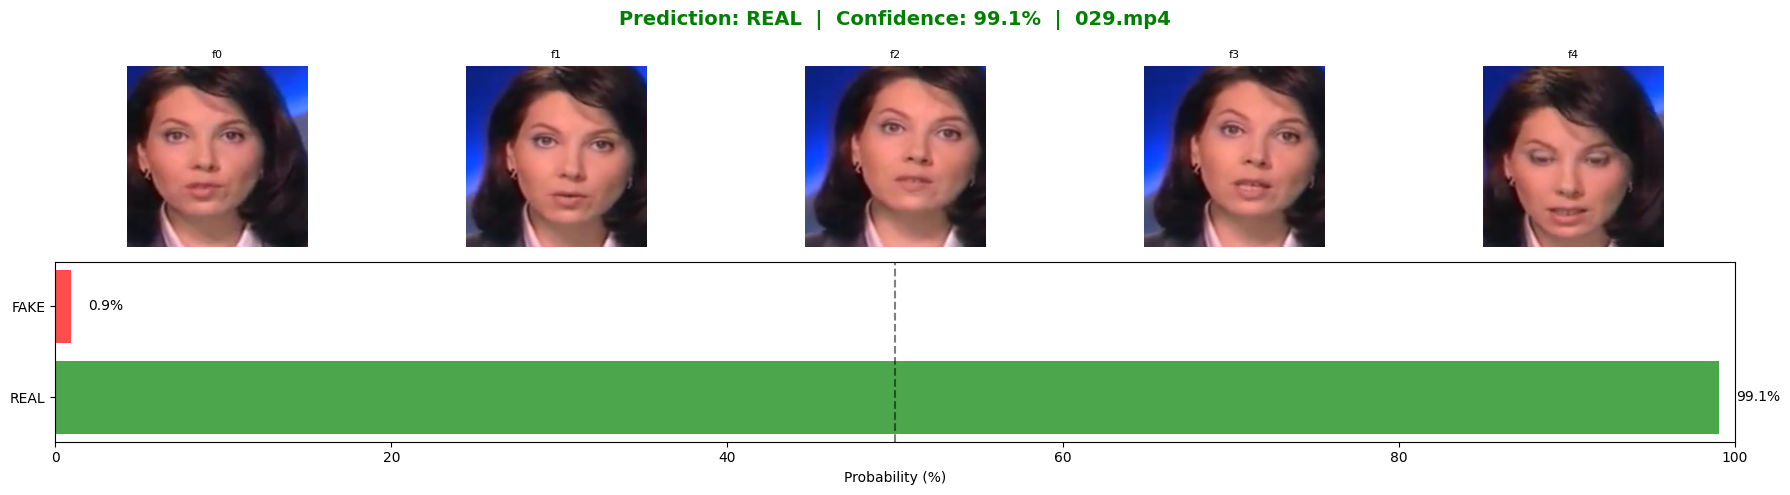


  Result     : REAL
  Confidence : 99.1%
  Fake prob  : 0.9%
  Real prob  : 99.1%
Analyzing: 000_003.mp4


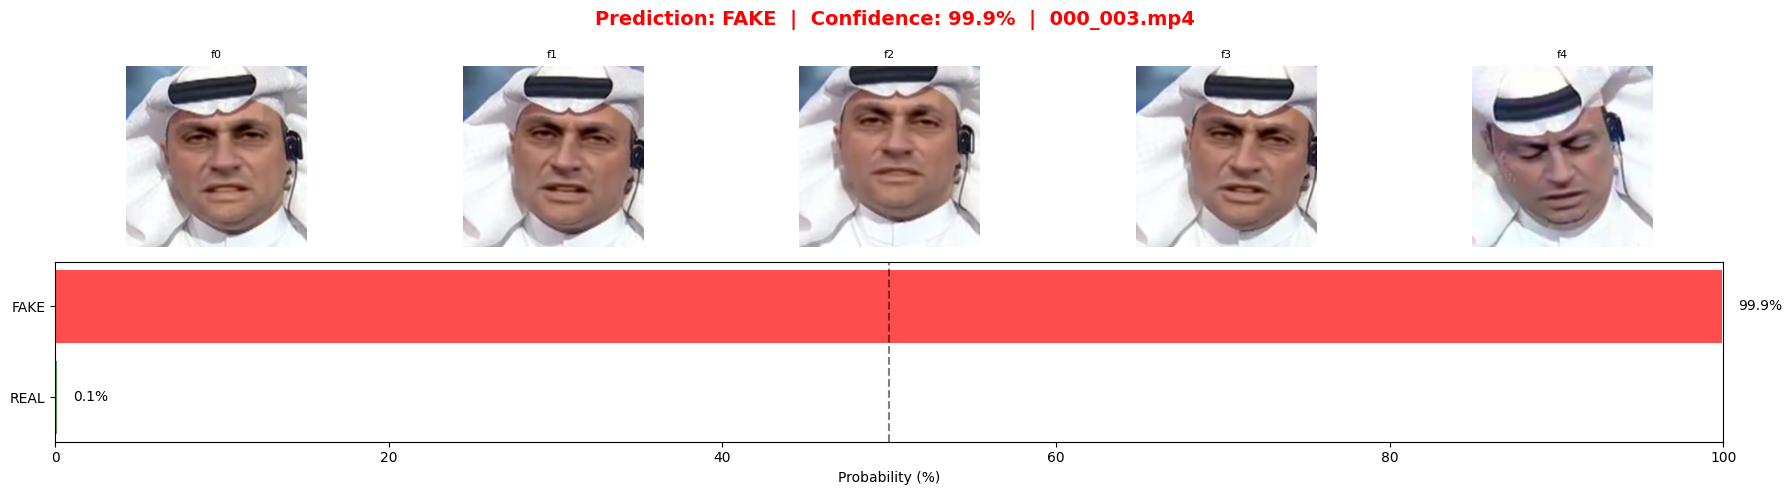


  Result     : FAKE
  Confidence : 99.9%
  Fake prob  : 99.9%
  Real prob  : 0.1%


In [33]:
test_videos = [
    f'/content/drive/MyDrive/DeepfakeProject/FaceForensics/original/029.mp4',
    f'/content/drive/MyDrive/DeepfakeProject/FaceForensics/Deepfakes/000_003.mp4',
]

for vpath in test_videos:
    if os.path.exists(vpath):
        result = predict(vpath)
        name   = vpath.split('/')[-1]
        show_prediction(result, video_name=name)
    else:
        print(f'Not found: {vpath}')